# 01 — Data and Model

**MotionFormer / AlphaMotion** · Stage 1 reviewer entry point

Owns config (single source of truth — dumped to `01_resources/configs/*.json`
for NB2 and NB3 to load). Algorithm code lives in `01_resources/scripts/` —
this notebook only **calls** those scripts and renders results.

| | |
|---|---|
| Reading time | ~5 min |
| Run time     | <5 min on RTX PRO 6000 |
| Trains       | only a 100-step smoke (no checkpoint saved) |
| Resource dir | `notebook/01_resources/` |
| Linked       | `note/motionformer-research-vision.md` §9.1.ter |

## Outline
0. Bootstrap (sys.path) + Configuration (env / data / training / 6 variants) — **owns the truth**
1. Reproducibility header
2. Data — AMASS canonical + Kimodo OOD (incl. `other`-bottleneck investigation)
3. Model — variant table, forward shape trace, two architecture diagrams
4. Training protocol (config display + 100-step smoke)
5. Sign-off (artifact list)

> All figures saved to disk; cells use `display(Image(filename=...))` so what
> you see inline is exactly what's on disk (paper-companion discipline).


## §0 Bootstrap + Configuration — single source of truth


In [1]:
# §0.1 Path setup — make 01_resources/scripts/ importable
import sys
from pathlib import Path
from IPython.display import Image, display
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
RESOURCES = Path("01_resources")
sys.path.insert(0, str(RESOURCES / "scripts"))


def show_and_save(fig, path):
    """NB-wide pattern: savefig + close + display from disk (one image, canonical)."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=120, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))


In [2]:
# §0.2 Environment
ENV = {
    "device": "cuda",
    "seed":   0,
    "conda_env": "rot",
    "data_root":        str(REPO_ROOT / "data"),
    "checkpoints_root": str(RESOURCES.parent / "02_resources/checkpoints"),
    "figures_root":     str(RESOURCES / "figures"),
}


In [3]:
# §0.3 Data
DATA = {
    "amass": {
        "npz":   f"{ENV['data_root']}/mixed_soma77.npz",   # Y-up corrected — NEVER _zup.npz
        "split": "canonical",
        "heldout_subjects_file": f"{ENV['data_root']}/splits.json",
    },
    "kimodo": {
        "npz":      f"{ENV['data_root']}/kimodo/kimodo_soma77.npz",
        "ood_only": True,
    },
    "skeleton":      {"name": "soma77", "n_joints": 77},
    "sample":        {"T": 90, "stride": 32, "T_max": 256},
    "action_labels": {"taxonomy": "12_family", "show_other_warning": True},
}


In [4]:
# §0.4 Training defaults (variants override what they need)
TRAIN_DEFAULT = {
    "optim":   {"lr": 3e-4, "weight_decay": 1e-5, "betas": [0.9, 0.95],
                "warmup_steps": 1000, "total_steps": 60000},
    "batch":   {"size": 32, "grad_accum": 1},
    # Loss weights for Stage-1 v2 (FM regime). User-chosen post-mentor-feedback:
    # high pos for endpoint accuracy; rot=1 since geodesic-style FM target already large;
    # root=2 lifts a small-magnitude term; fk=2 binds rot↔pos at extrapolated endpoint.
    "loss":    {"pos_weight": 10.0, "rot_weight": 1.0, "root_weight": 2.0, "fk_weight": 2.0},
    "masking": {
        "modes":      ["random", "joint", "time", "keyframe"],
        "random_p":   0.30,
        "keyframe_p": 0.10,
        # NOTE: 'kinematic_chain' intentionally omitted — empirically falsified
        # (mixed_fixed30: 0.06 → 0.22, 4× degradation). Use 'joint' for damage.
    },
    "eval": {"every_steps": 2000, "amass_heldout_batches": 64},
    "io":   {"log_every": 100, "save_every": 5000, "ckpt_keep_last": 3},
}


In [5]:
# §0.5 Six model variants — pair-first ablation grid
def _mf(use_pair, use_opm, use_triangle, desc):
    return {
        "description": desc,
        "model": dict(arch="motionformer", hidden=128, pair_hidden=32, depth=6,
                      heads=4, pair_heads=4, opm_chunk=16, tri_hidden=16,
                      use_pair=use_pair, use_opm=use_opm, use_triangle=use_triangle),
    }

VARIANTS = {
    "full":          _mf(True,  True,  True,  "Full MotionFormer: pair-first trunk + OPM + triangle refiner"),
    "opm_only":      _mf(True,  True,  False, "OPM gateway only — distributed pair, no triangle shaping"),
    "triangle_only": _mf(True,  False, True,  "Triangle refiner only — no OPM gateway"),
    "pair_static":   _mf(True,  False, False, "Pair tensor present but never updated (static bias)"),
    "axial_only":    _mf(False, False, False, "Axial attention only — no pair tensor at all"),
    "baseline": {
        "description": "Plain transformer baseline — no pair tensor, no Evoformer-style structure",
        "model": dict(arch="baseline", hidden=128, depth=12, heads=4, ffn_mult=4),
    },
}


In [6]:
# §0.6 Dump config to 01_resources/configs/ for NB2/NB3
import json
CFG_DIR = RESOURCES / "configs"
CFG_DIR.mkdir(parents=True, exist_ok=True)
for name, obj in [("env", ENV), ("data", DATA),
                  ("train_default", TRAIN_DEFAULT), ("variants", VARIANTS)]:
    (CFG_DIR / f"{name}.json").write_text(json.dumps(obj, indent=2))
print(f"wrote {len(list(CFG_DIR.glob('*.json')))} config files to {CFG_DIR}/")


wrote 4 config files to 01_resources/configs/


### §0.7 Data manifest — committable metadata

`01_resources/data_cache/data_manifest.json` is small (~2 KB) and *commits*
to git, so reviewers cloning this repo see what data was used (counts /
durations / split protocol) without needing the 92 GB raw download.


In [7]:
# §0.7 Generate committable data manifest
import hashlib, json
from data_loader import (
    load_amass_canonical, load_kimodo_ood,
    load_amass_heldout_labeled, load_amass_heldout_other,
    per_source_breakdown, duration_breakdown, FPS, FRAMES_PER_CLIP,
)

train_, held_     = load_amass_canonical(DATA)
kim_, hl_, ho_    = load_kimodo_ood(DATA), load_amass_heldout_labeled(DATA), load_amass_heldout_other(DATA)
dur_ = duration_breakdown(DATA, [
    ("amass_train",          train_),
    ("amass_heldout_full",   held_),
    ("amass_heldout_labeled", hl_),
    ("amass_heldout_other",  ho_),
    ("kimodo_test",          kim_),
])

# Cheap fingerprint of splits.json so reviewer can verify they have the same split definitions
splits_md5 = hashlib.md5(Path(DATA["amass"]["heldout_subjects_file"]).read_bytes()).hexdigest()

manifest = {
    "stage": "1",
    "protocol": "v1 (synthetic in test only — see data_loader docstring)",
    "fps": FPS,
    "frames_per_clip": FRAMES_PER_CLIP,
    "seconds_per_clip": FRAMES_PER_CLIP / FPS,
    "data_root": ENV["data_root"],
    "splits_file_md5": splits_md5,
    "per_source_raw": per_source_breakdown(DATA),
    "splits_used": dur_,
}
CACHE_DIR = RESOURCES / "data_cache"; CACHE_DIR.mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "data_manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"wrote {CACHE_DIR / 'data_manifest.json'}")


wrote 01_resources/data_cache/data_manifest.json


## §1 Reproducibility header


In [8]:
import sys, subprocess, random
import numpy as np, torch

random.seed(ENV["seed"]); np.random.seed(ENV["seed"]); torch.manual_seed(ENV["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(ENV["seed"])

print("python   :", sys.version.split()[0])
print("torch    :", torch.__version__)
print("cuda     :", torch.version.cuda, "| available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device   :", torch.cuda.get_device_name(0))
print("commit   :", subprocess.check_output(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "--short", "HEAD"]).decode().strip())
print("seed     :", ENV["seed"])
print("conda    :", ENV["conda_env"])


python   : 3.12.12
torch    : 2.9.1+cu128
cuda     : 12.8 | available: True
device   : NVIDIA RTX PRO 6000 Blackwell Workstation Edition
commit   : 4a6684c
seed     : 0
conda    : rot


## §2 Data

Two sources:

- **AMASS** — real motion capture. Canonical heldout split (by subject) —
  random 8:2 leaks identity.
- **Kimodo** — synthetic, family-prompted procedural pipeline. **OOD only** —
  never enters training mix.

> ⚠ `mixed_soma77.npz` is Y-up corrected. `_zup.npz` is broken — do not use.


In [9]:
# §2.1 Load splits + per-source breakdown + duration table
#
# Stage-1 v1 protocol (synthetic for TEST only):
#   - train          = AMASS canonical train (subject-wise split)
#   - heldout (real) = AMASS canonical heldout
#   - test (OOD)     = Kimodo (entire 2k subset, balanced families)
#   - test (real-labeled)   = AMASS heldout ∩ labeled
#   - test (real-other)     = AMASS heldout ∩ 'other'
from data_loader import (
    load_amass_canonical, load_kimodo_ood,
    load_amass_heldout_labeled, load_amass_heldout_other,
    per_source_breakdown, duration_breakdown,
)
import pandas as pd

train, heldout = load_amass_canonical(DATA)
kimodo         = load_kimodo_ood(DATA)
held_labeled   = load_amass_heldout_labeled(DATA)
held_other     = load_amass_heldout_other(DATA)

splits = [
    ("AMASS train",                   train),
    ("AMASS heldout (full)",          heldout),
    ("  ↳ heldout labeled (A-eval)",  held_labeled),
    ("  ↳ heldout other  (A-other)",  held_other),
    ("Kimodo OOD test (K-eval)",      kimodo),
]
dur = duration_breakdown(DATA, splits)
pd.DataFrame(dur).T


,clips,seconds,minutes,hours
AMASS train,5066.0,15198.0,253.3,4.22
AMASS heldout (full),618.0,1854.0,30.9,0.52
↳ heldout labeled (A-eval),264.0,792.0,13.2,0.22
↳ heldout other (A-other),354.0,1062.0,17.7,0.29
Kimodo OOD test (K-eval),2000.0,6000.0,100.0,1.67


In [10]:
# §2.1.1 Per-source breakdown (raw mixed npz, before splitting)
br = per_source_breakdown(DATA)
pd.DataFrame({k: {"total": v["total"], "n_subjects": len(v["subsets"])}
              for k, v in br.items()}).T


,total,n_subjects
amass,7315,365
hy_motion,41,1
kimodo,2000,1


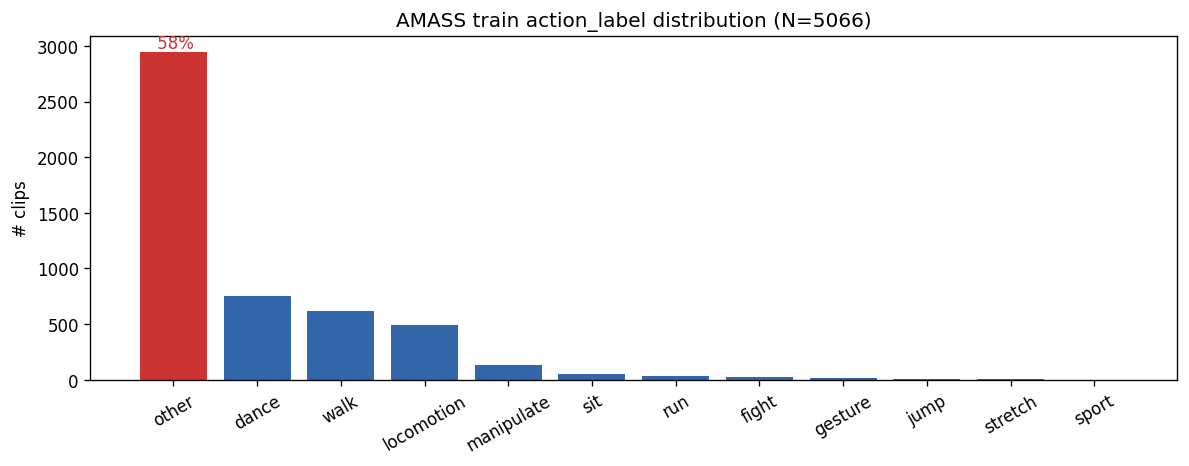

In [11]:
# §2.2 action_label distribution on AMASS train — exposes "other" bottleneck
from action_labels import family_distribution
from viz import plot_family_distribution

dist = family_distribution(train)
fig  = plot_family_distribution(
    dist,
    title=f"AMASS train action_label distribution (N={len(train)})",
    highlight="other",
)
show_and_save(fig, RESOURCES / "figures/01__family_dist.png")


### §2.2.1 The "other" data bottleneck — exploratory investigation

`other` is **58%** of AMASS train. That's not noise — it's all real human motion
that our 12-family regex didn't classify. Two questions:

1. **Where does "other" come from?** Is it concentrated in specific AMASS
   subsets (suggesting those subsets just lack captions), or spread across all
   subsets (suggesting our taxonomy is too coarse)?
2. **Does "other" have hidden structure?** If we cluster it without supervision,
   do we recover meaningful sub-families (e.g. "warmups", "transitions",
   "object-interaction") that we could re-label?

> 🔬 **The real version of (2) lives in NB02 §5** — once Stage-1 checkpoints
> exist, the same kind of clustering uses **trained pair-tensor encoder
> embeddings** on the *full* clip (not raw mid-frame joints). That's the
> proper "encode → discover style" pipeline. The cell below is a placeholder
> sanity check: even a crude single-frame joint feature already shows enough
> structure to validate the direction.


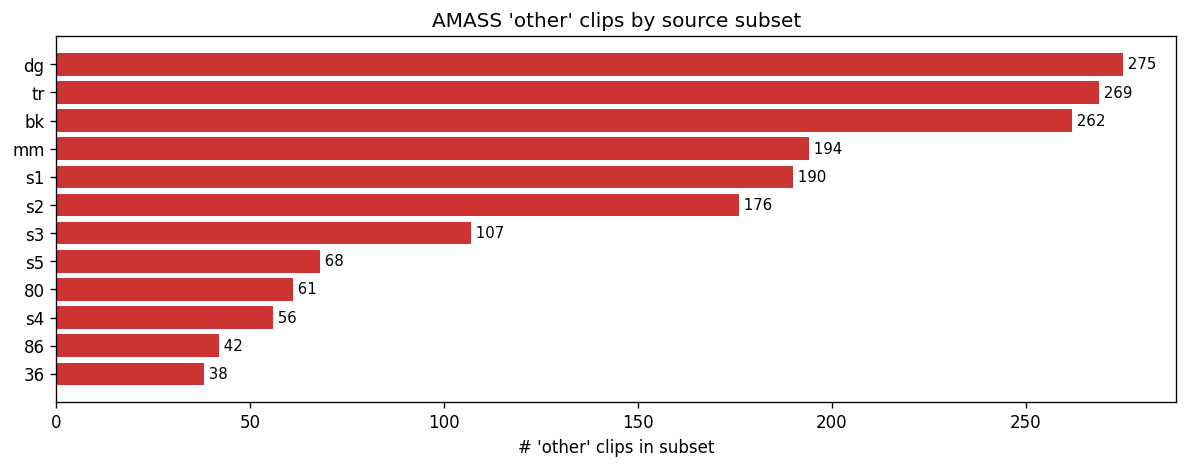

In [12]:
# §2.2.1.a Per-subset breakdown of "other" within AMASS
from data_loader import other_subset_breakdown
from viz import plot_other_subset_breakdown

other_by_subset = other_subset_breakdown(DATA, source="amass")
fig = plot_other_subset_breakdown(other_by_subset, top_k=12)
show_and_save(fig, RESOURCES / "figures/01__other_subsets.png")


'other' samples: 4168, feature dim: 231 (= 77 joints × 3 coords)


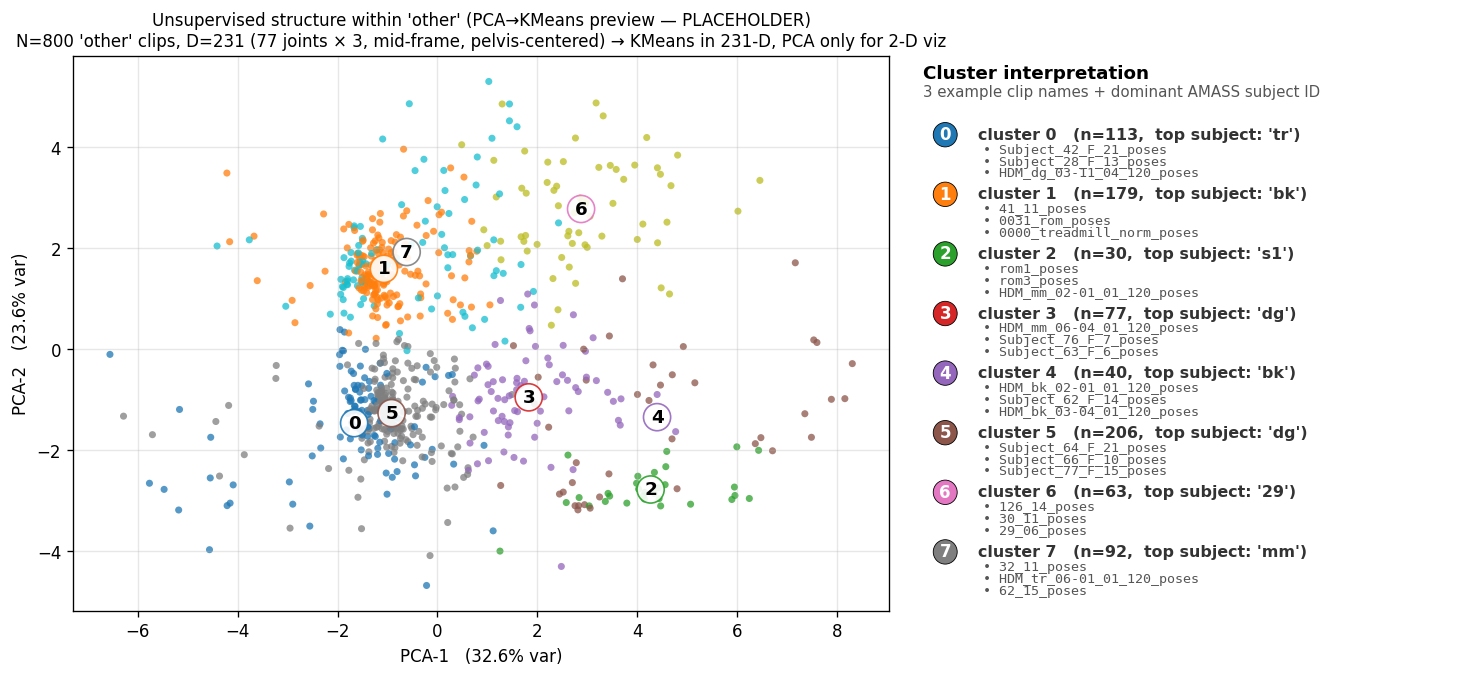

In [13]:
# §2.2.1.b Unsupervised clustering preview on "other"
#
# Pipeline (placeholder — NB02 §5 replaces this with trained encoder embeddings):
#   1. Pick AMASS-other clips                              → 2941 clips
#   2. Per clip: take frame t=45, joint positions [77,3]
#   3. Pelvis-center, flatten                              → 231-D feature
#   4. KMeans(K=8) in 231-D                                → cluster labels
#   5. PCA(2) ONLY for visualization                       → 2-D scatter
#
# What axes mean: PC1, PC2 are the linear directions of MAX variance in the
# 231-D joint-position space. They have no a-priori physical meaning — the
# titles below show what fraction of total variance each axis captures.
from data_loader import other_feature_matrix
from viz import plot_other_unsupervised

X, names, subsets = other_feature_matrix(DATA, source="amass", frame_idx=45)
print(f"'other' samples: {len(X)}, feature dim: {X.shape[1]} (= 77 joints × 3 coords)")

fig = plot_other_unsupervised(X, names, subsets, n_clusters=8,
                               n_samples=800, seed=ENV["seed"])
show_and_save(fig, RESOURCES / "figures/01__other_unsupervised.png")


### §2.3 / §2.4 Mesh playback (SMPL-X mesh GIFs)

Static skeleton grids are unintelligible for motion. We render true SMPL-X mesh
playback via standalone LBS (`lbs.py`) + offscreen pyrender (`mesh_render.py`),
using the SOMA-77 skin asset copied from Kimodo.

For each source we render **one representative GIF per family**, picking the
first sample of each family for reproducibility.


rendering 6 AMASS family GIFs to 01_resources/figures/amass_family_gifs/


  dance            141 KB


  walk             106 KB


  locomotion       174 KB


  manipulate        94 KB


  sit              219 KB


  run              215 KB

--- dance ---


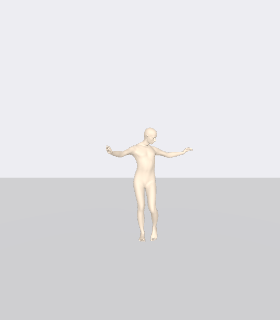


--- walk ---


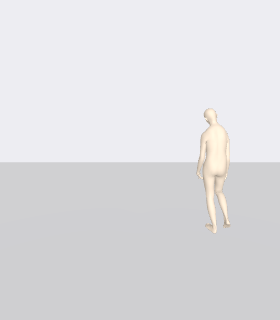


--- locomotion ---


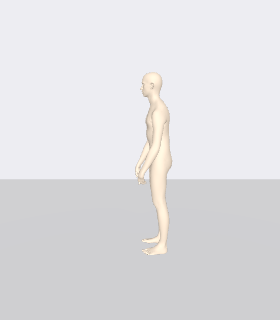

In [14]:
# §2.3 AMASS family GIFs (one clip per family, mesh playback)
import numpy as np
from lbs import load_skin, lbs_sequence
from mesh_render import render_mesh_gif

skin = load_skin(RESOURCES / "assets/skin_standard.npz")
raw_npz = np.load(DATA["amass"]["npz"], allow_pickle=True)

# group AMASS train indices by family
fams = sorted({lbl for lbl, c in dist.items() if c > 0 and lbl != "other"},
              key=lambda k: -dist[k])[:6]  # top-6 (excl. other; rendering all is wasteful)

GIF_DIR = RESOURCES / "figures/amass_family_gifs"; GIF_DIR.mkdir(parents=True, exist_ok=True)
print(f"rendering {len(fams)} AMASS family GIFs to {GIF_DIR}/")

stride = 3                                    # 90 → 30 frames
for fam in fams:
    fam_local = [i for i in range(len(train))
                 if str(train.dataset.action_label[train.indices[i]]) == fam]
    if not fam_local:
        continue
    pick_global = train.indices[fam_local[0]]
    grot = raw_npz["global_rot_mats"][pick_global][::stride]
    jts  = raw_npz["joints_world"][pick_global][::stride]
    verts = lbs_sequence(skin, grot, jts)
    out = GIF_DIR / f"{fam}.gif"
    render_mesh_gif(verts, skin["faces"], out, viewport=(280, 320), fps=10)
    print(f"  {fam:<14}  {out.stat().st_size//1024:>4} KB")

# Inline display: top-3 families
for fam in fams[:3]:
    p = GIF_DIR / f"{fam}.gif"
    if p.exists():
        print(f"\n--- {fam} ---")
        display(Image(filename=str(p)))


rendering 6 Kimodo family GIFs to 01_resources/figures/kimodo_family_gifs/


  other            201 KB


  stretch          249 KB


  fight            158 KB


  gesture          216 KB


  walk              57 KB


  jump             207 KB

--- other ---


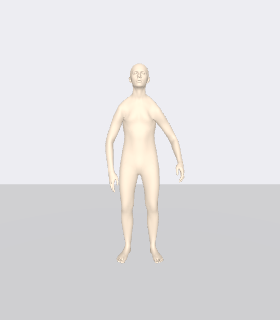


--- stretch ---


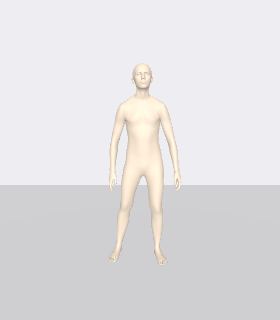


--- fight ---


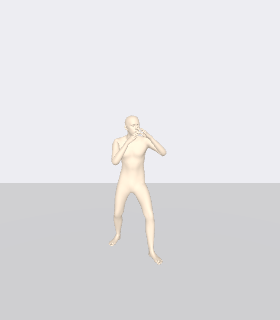

In [15]:
# §2.4 Kimodo family GIFs (one clip per family)
from data_loader import kimodo_family_index

kfi = kimodo_family_index(DATA)
kimodo_fams = sorted(kfi, key=lambda k: -len(kfi[k]))[:6]

KIMODO_GIF_DIR = RESOURCES / "figures/kimodo_family_gifs"; KIMODO_GIF_DIR.mkdir(parents=True, exist_ok=True)
print(f"rendering {len(kimodo_fams)} Kimodo family GIFs to {KIMODO_GIF_DIR}/")

for fam in kimodo_fams:
    if not kfi[fam]:
        continue
    pick_global = kimodo.indices[kfi[fam][0]]
    grot = raw_npz["global_rot_mats"][pick_global][::stride]
    jts  = raw_npz["joints_world"][pick_global][::stride]
    verts = lbs_sequence(skin, grot, jts)
    out = KIMODO_GIF_DIR / f"{fam}.gif"
    render_mesh_gif(verts, skin["faces"], out, viewport=(280, 320), fps=10)
    print(f"  {fam:<14}  {out.stat().st_size//1024:>4} KB")

# Inline display: top-3 families
for fam in kimodo_fams[:3]:
    p = KIMODO_GIF_DIR / f"{fam}.gif"
    if p.exists():
        print(f"\n--- {fam} ---")
        display(Image(filename=str(p)))


### §2.5 Data caveats
- `_zup.npz` is **broken** despite the name — do not use.
- Kimodo never enters training mix.
- AMASS uses **canonical subject split**; random 8:2 forbidden.
- AMASS "other" is currently **~58%** (memory said 77% — caption pipeline has
  improved). It dominates and motivates Stage 2 caption integration. The
  unsupervised preview above (§2.2.1.b) shows there IS hidden structure,
  validating the future research direction.


## §3 Model

AlphaMotion is a **pair-first** whole-body controller (vision doc §9.1.ter).
Trunk maintains a `[J × J]` pair tensor refined by:

- **(a) OPM gateway** — input-conditioned outer-product mixing
- **(b) Triangle refiner** — modular geometry shaping (validated as Claim 2 in NB02)


In [16]:
# §3.1 Variant table (driven by VARIANTS dict from §0.5)
import pandas as pd

rows = [{
    "name":         name,
    "description":  v["description"],
    "arch":         v["model"]["arch"],
    "use_pair":     v["model"].get("use_pair", "-"),
    "use_opm":      v["model"].get("use_opm",  "-"),
    "use_triangle": v["model"].get("use_triangle", "-"),
} for name, v in VARIANTS.items()]
pd.DataFrame(rows).set_index("name")


,description,arch,use_pair,use_opm,use_triangle
name,,,,,
full,Full MotionFormer: pair-first trunk + OPM + tr...,motionformer,True,True,True
opm_only,"OPM gateway only — distributed pair, no triang...",motionformer,True,True,False
triangle_only,Triangle refiner only — no OPM gateway,motionformer,True,False,True
pair_static,Pair tensor present but never updated (static ...,motionformer,True,False,False
axial_only,Axial attention only — no pair tensor at all,motionformer,False,False,False
baseline,"Plain transformer baseline — no pair tensor, n...",baseline,-,-,-


In [17]:
# §3.2 Param counts per variant + forward shape trace on `full`
from model_builder import build_from_spec
from data_loader import sample_batch
import torch

T, J, C = DATA["sample"]["T"], DATA["skeleton"]["n_joints"], 3
print(f"input shape: [B, T={T}, J={J}, C={C}]")
print()
for name, v in VARIANTS.items():
    m, _ = build_from_spec(v["model"], T=T, J=J, C=C)
    n = sum(p.numel() for p in m.parameters())
    print(f"  {name:<14}  params={n/1e6:>5.2f}M  arch={type(m).__name__}")

print()
print("--- forward smoke on `full` (FM regime: velocity field at t=1) ---")
model_full, cfg_full = build_from_spec(VARIANTS["full"]["model"], T=T, J=J, C=C)
model_full.eval()
batch = sample_batch(train, n=2)
B = batch["pos"].shape[0]

# FM forward signature: (x_pos_t, x_rot_t, x_root_t, t, mask=None).
# At t=1 (data state) the model sees clean ground truth; output is the
# velocity field at that operating point. This is what eval scripts use to
# extract trunk activations (pair tensor / MSA hidden) for §3 / §5 analyses.
t = torch.ones(B)
with torch.no_grad():
    out = model_full(batch["pos"], batch["rot6d"], batch["root"], t)
print(f"  input.pos       : {tuple(batch['pos'].shape)}")
print(f"  input.rot6d     : {tuple(batch['rot6d'].shape)}")
print(f"  input.root      : {tuple(batch['root'].shape)}")
print(f"  input.t         : {tuple(t.shape)}")
for k, v in out.items():
    print(f"  output.{k:<7} : {tuple(v.shape)}  (velocity field, NOT a direct prediction)")


input shape: [B, T=90, J=77, C=3]

  full            params= 2.21M  arch=MotionFormer
  opm_only        params= 2.16M  arch=MotionFormer
  triangle_only   params= 2.14M  arch=MotionFormer
  pair_static     params= 2.03M  arch=MotionFormer
  axial_only      params= 1.84M  arch=MotionFormer
  baseline        params= 2.44M  arch=BaselineTransformer

--- forward smoke on `full` (FM regime: velocity field at t=1) ---


/home/arenalabs/miniconda3/envs/rot/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  input.pos       : (2, 90, 77, 3)
  input.rot6d     : (2, 90, 77, 6)
  input.root      : (2, 90, 3)
  input.t         : (2,)
  output.pos     : (2, 90, 77, 3)  (velocity field, NOT a direct prediction)
  output.rot6d   : (2, 90, 77, 6)  (velocity field, NOT a direct prediction)
  output.root    : (2, 90, 3)  (velocity field, NOT a direct prediction)


### §3.3 AlphaMotion architecture (full variant)

Dual-track Evoformer-style: MSA tensor `[B,T,J,H]` and Pair tensor `[B,J,J,P]`
co-evolve through `× 6` blocks, with **OPM** injecting MSA→Pair and **bias**
flowing Pair→MSA at each row attention.

> Inline figure below is a matplotlib auto-render. The **paper-grade source** is
> at `01_resources/diagrams/alphamotion_arch.drawio` — open in
> [app.diagrams.net](https://app.diagrams.net) or VS Code (Draw.io extension)
> to view, edit, and export PDF/SVG for paper inclusion. The .drawio embeds the
> mesh insets as base64, so it's self-contained.


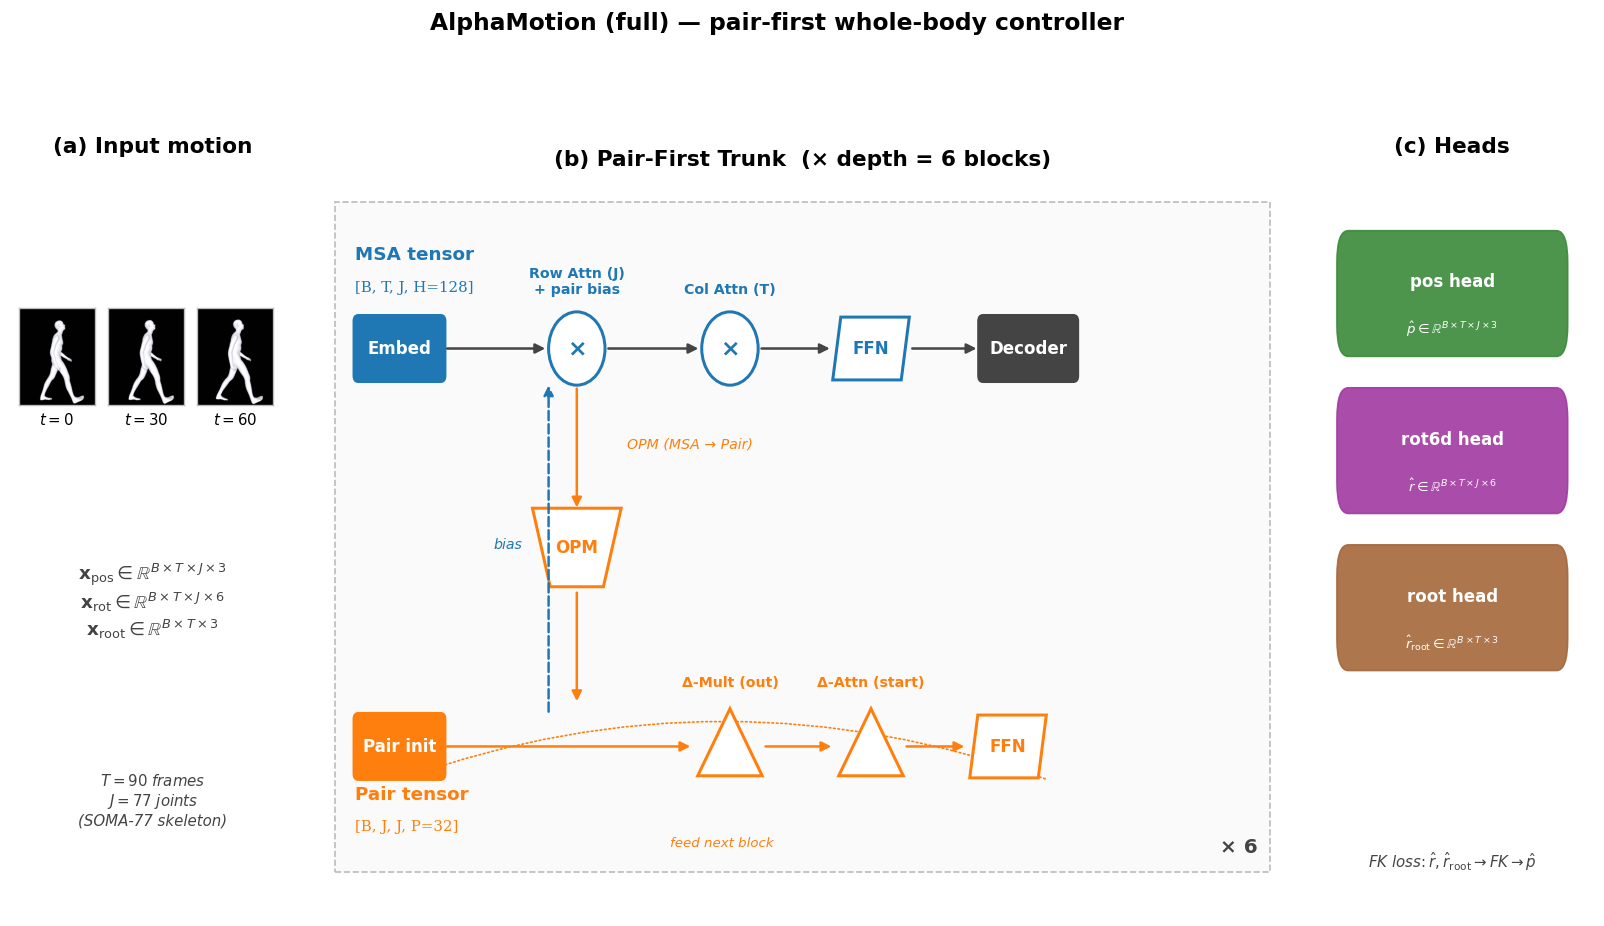

In [18]:
# §3.3 AlphaMotion arch — matplotlib auto-render (inline preview)
from viz import plot_alphamotion_arch

mesh_insets = sorted((RESOURCES / "figures/insets").glob("walk_t*.png"))
fig = plot_alphamotion_arch(cfg_full, T=T, J=J,
                             mesh_inset_paths=[str(p) for p in mesh_insets])
show_and_save(fig, RESOURCES / "figures/01__alphamotion_arch.png")


### §3.4 Baseline architecture

Plain transformer encoder stack — no pair tensor. Ablation control for Claim 1
(NB02 §2): does the pair-tensor / OPM / triangle structure matter at all?


/home/arenalabs/miniconda3/envs/rot/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


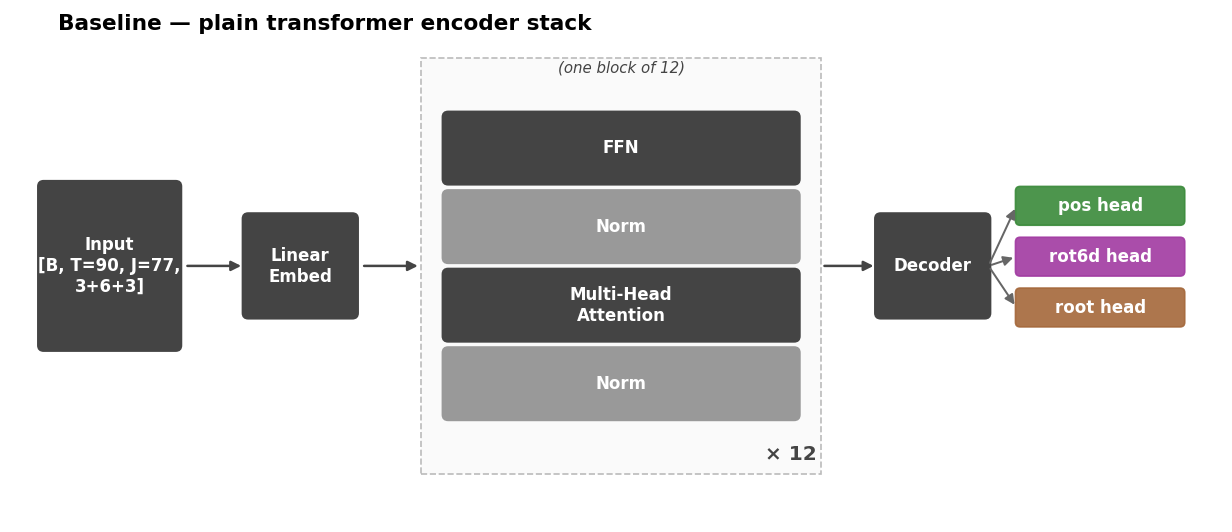

In [19]:
# §3.4 Baseline arch — matplotlib auto-render (inline preview)
from viz import plot_baseline_arch
_, cfg_baseline = build_from_spec(VARIANTS["baseline"]["model"], T=T, J=J, C=C)
fig = plot_baseline_arch(cfg_baseline, T=T, J=J)
show_and_save(fig, RESOURCES / "figures/01__baseline_arch.png")


## §4 Training protocol

Hyperparameters live in §0.4 `TRAIN_DEFAULT` and §0.5 `VARIANTS`. This notebook
runs only a **100-step smoke** (no checkpoint saved) to verify env + data + model
descend on a real loss curve.


In [20]:
# §4.1 TRAIN_DEFAULT as a flat table
import pandas as pd
def _flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = f"{prefix}{k}"
        if isinstance(v, dict):
            out.update(_flatten(v, prefix=f"{key}."))
        else:
            out[key] = v
    return out
pd.DataFrame.from_dict(_flatten(TRAIN_DEFAULT), orient="index", columns=["value"])


,value
optim.lr,0.0003
optim.weight_decay,0.00001
optim.betas,"[0.9, 0.95]"
optim.warmup_steps,1000
optim.total_steps,60000
batch.size,32
batch.grad_accum,1
loss.pos_weight,10.0
loss.rot_weight,1.0
loss.root_weight,2.0


{
  "device": "cuda",
  "regime": "fm_pos_only",
  "T": 90,
  "J": 77,
  "C": 3,
  "n_steps": 100,
  "wall_seconds": 26.75,
  "loss_first": 1.7912499904632568,
  "loss_last": 0.4032607078552246
}


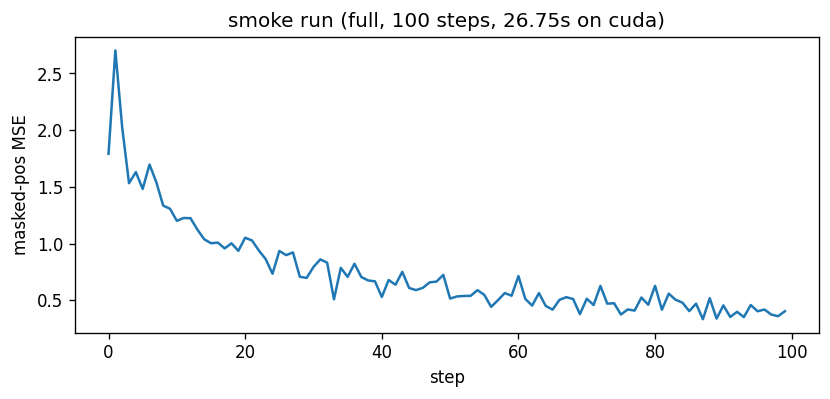

✓ smoke descended: 1.7912 -> 0.4033


In [21]:
# §4.2 100-step smoke run — does NOT save weights
import json, matplotlib.pyplot as plt
from train import smoke_run

losses, info = smoke_run(VARIANTS["full"], TRAIN_DEFAULT, train,
                         n_steps=100, device=ENV["device"], seed=ENV["seed"])
print(json.dumps(info, indent=2))

SMOKE_DIR = RESOURCES / "smoke_logs"; SMOKE_DIR.mkdir(parents=True, exist_ok=True)
(SMOKE_DIR / "full__smoke_loss.json").write_text(json.dumps({"losses": losses, "info": info}, indent=2))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(losses)
ax.set_xlabel("step"); ax.set_ylabel("masked-pos MSE")
ax.set_title(f"smoke run (full, {info['n_steps']} steps, {info['wall_seconds']}s on {info['device']})")
show_and_save(fig, SMOKE_DIR / "full__smoke_loss.png")

assert losses[-1] < losses[0] * 0.95, f"smoke did not descend: {losses[0]:.4f} -> {losses[-1]:.4f}"
print(f"✓ smoke descended: {losses[0]:.4f} -> {losses[-1]:.4f}")


## §5 Sign-off


In [22]:
ARTIFACTS = [
    RESOURCES / "configs/env.json",
    RESOURCES / "configs/data.json",
    RESOURCES / "configs/train_default.json",
    RESOURCES / "configs/variants.json",
    RESOURCES / "figures/01__family_dist.png",
    RESOURCES / "figures/01__other_subsets.png",
    RESOURCES / "figures/01__other_unsupervised.png",
    RESOURCES / "figures/01__alphamotion_arch.png",
    RESOURCES / "figures/01__baseline_arch.png",
    RESOURCES / "diagrams/alphamotion_arch.drawio",
    RESOURCES / "diagrams/baseline_arch.drawio",
    RESOURCES / "smoke_logs/full__smoke_loss.png",
    RESOURCES / "smoke_logs/full__smoke_loss.json",
]
missing = [p for p in ARTIFACTS if not p.exists()]
for p in ARTIFACTS:
    flag = "✓" if p.exists() else "✗"
    size = f"{p.stat().st_size:>7} bytes" if p.exists() else "(missing)"
    print(f"  {flag}  {str(p):<60s}  {size}")

# Family GIFs (count, not enumerated)
for sub in [RESOURCES / "figures/amass_family_gifs",
            RESOURCES / "figures/kimodo_family_gifs"]:
    if sub.exists():
        gifs = list(sub.glob("*.gif"))
        print(f"  ✓  {sub} ({len(gifs)} GIFs)")

assert not missing, f"missing artifacts: {missing}"
print("\nNB01 complete.")


  ✓  01_resources/configs/env.json                                     216 bytes
  ✓  01_resources/configs/data.json                                    561 bytes
  ✓  01_resources/configs/train_default.json                           629 bytes
  ✓  01_resources/configs/variants.json                               2131 bytes
  ✓  01_resources/figures/01__family_dist.png                        43045 bytes
  ✓  01_resources/figures/01__other_subsets.png                      32063 bytes
  ✓  01_resources/figures/01__other_unsupervised.png                233373 bytes
  ✓  01_resources/figures/01__alphamotion_arch.png                  134410 bytes
  ✓  01_resources/figures/01__baseline_arch.png                      46014 bytes
  ✓  01_resources/diagrams/alphamotion_arch.drawio                   79637 bytes
  ✓  01_resources/diagrams/baseline_arch.drawio                       6608 bytes
  ✓  01_resources/smoke_logs/full__smoke_loss.png                    39564 bytes
  ✓  01_resources/smoke_logs